In [1]:
!git clone https://github.com/ZinanAguirre/CSCI467Project.git

fatal: destination path 'CSCI467Project' already exists and is not an empty directory.


In [2]:
%cd CSCI467Project

/content/CSCI467Project


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from torch import nn
from torch.utils.data import DataLoader
import copy
from modules import func, networks
import math

In [4]:

BATCH_SIZE = 128
MAX_ITERS = 5000
LAMBDA = 2e-4
IN_CHANNELS = 3
CONV1 = 64
CONV2 = 64
FC1 = 256
FC2 = 256
OUT = 10
SPATIAL = 16
VALSIZE = 5000
CONV_PRUNE_RATE  = 0.10
FC_PRUNE_RATE    = 0.20


MIN_FILTERS      = 2
MIN_NEURONS      = 2

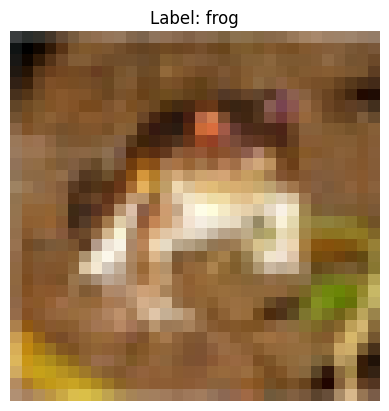

In [5]:
# ── CIFAR-10 data 
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

data = datasets.CIFAR10(
    root="data", train=True, download=True, transform=transform
)
test_data = datasets.CIFAR10(
    root="data", train=False, download=True, transform=transform
)

image, label = data[0]
plt.imshow(image.permute(1, 2, 0).numpy() * np.array([0.2023, 0.1994, 0.2010])
           + np.array([0.4914, 0.4822, 0.4465]))
plt.title(f"Label: {data.classes[label]}")
plt.axis("off")
plt.show()

In [6]:
targets = np.array(data.targets)
idx = list(range(len(data)))

train_idx, val_idx = train_test_split(
    idx, test_size=VALSIZE, stratify=targets, random_state=42, shuffle=True
)

train_data = Subset(data, train_idx)
val_data   = Subset(data, val_idx)

In [7]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(device)

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader   = DataLoader(val_data,   batch_size=BATCH_SIZE)
test_dataloader  = DataLoader(test_data,  batch_size=BATCH_SIZE)

cuda


In [8]:
model = networks.Conv2(
    in_channels=IN_CHANNELS, c1=CONV1, c2=CONV2,
    fc1=FC1, fc2=FC2, out=OUT, spatial=SPATIAL
).to(device)

loss_fn = nn.CrossEntropyLoss()


initial_conv = [[l.weight.data.clone(), l.bias.data.clone()]
                for l in model.conv_stack if isinstance(l, nn.Conv2d)]

initial_fc   = [[l.weight.data.clone(), l.bias.data.clone()]
                for l in model.linear_relu_stack if isinstance(l, nn.Linear)]

# Index lists: which original filter/neuron indices are still alive.
# These shrink each round but always index into initial_conv / initial_fc.
conv_idx = [
    list(range(initial_conv[0][0].shape[0])),
    list(range(initial_conv[1][0].shape[0])),
]
fc_idx = [
    list(range(initial_fc[0][0].shape[0])),
    list(range(initial_fc[1][0].shape[0])),
    list(range(initial_fc[2][0].shape[0])),
]

def remove_idx(idx_list, to_remove_set):
    """Drop positions in to_remove_set from idx_list.
    to_remove_set contains positions within the current pruned layer."""
    return [v for j, v in enumerate(idx_list) if j not in to_remove_set]

In [9]:
# Iterative structured pruning loop - LTH reset via index tracking

out_log   = []
snapshots = {}
MAX_ROUNDS = 200
S2 = SPATIAL * SPATIAL 

for round_i in range(MAX_ROUNDS):

    cur_conv = [l for l in model.conv_stack if isinstance(l, nn.Conv2d)]
    cur_fc   = [l for l in model.linear_relu_stack if isinstance(l, nn.Linear)]

    cur_conv[0].weight.data = initial_conv[0][0][conv_idx[0]].clone()
    cur_conv[0].bias.data   = initial_conv[0][1][conv_idx[0]].clone()

    cur_conv[1].weight.data = initial_conv[1][0][conv_idx[1]][:, conv_idx[0]].clone()
    cur_conv[1].bias.data   = initial_conv[1][1][conv_idx[1]].clone()

    expanded = []
    for f in conv_idx[1]:
        expanded.extend(range(f * S2, (f + 1) * S2))
    cur_fc[0].weight.data = initial_fc[0][0][fc_idx[0]][:, expanded].clone()
    cur_fc[0].bias.data   = initial_fc[0][1][fc_idx[0]].clone()

    cur_fc[1].weight.data = initial_fc[1][0][fc_idx[1]][:, fc_idx[0]].clone()
    cur_fc[1].bias.data   = initial_fc[1][1][fc_idx[1]].clone()


    cur_fc[2].weight.data = initial_fc[2][0][:, fc_idx[1]].clone()
    cur_fc[2].bias.data   = initial_fc[2][1].clone()

    # Train
    optimizer = torch.optim.Adam(model.parameters(), lr=LAMBDA)
    best_iter = networks.trainIter(
        train_dataloader, val_dataloader,
        model, loss_fn, optimizer, device, MAX_ITERS, Verbose=False
    )
    acc = networks.test(test_dataloader, model, loss_fn, device)
    out_log.append((best_iter, acc))
    print(f'Round {round_i:3d} | best_iter={best_iter:6d} | test_acc={acc:.1f}%')


    trained_conv = [[l.weight.data.clone(), l.bias.data.clone()] for l in cur_conv]
    trained_fc   = [[l.weight.data.clone(), l.bias.data.clone()] for l in cur_fc]

    # Stop conditions
    if any(len(idx) <= MIN_FILTERS for idx in conv_idx):
        print('Conv layers at minimum size - stopping.')
        break
    if any(len(idx) <= MIN_NEURONS for idx in fc_idx[:-1]):
        print('FC hidden layers at minimum size - stopping.')
        break

    # PRUNE: update index lists only.
    # initial_conv and initial_fc remain untouched.
    conv_remove = func.least_magnitude_filters_per_layer(
        trained_conv, prune_rate=CONV_PRUNE_RATE
    )
    conv_idx[0] = remove_idx(conv_idx[0], set(conv_remove[0]))
    conv_idx[1] = remove_idx(conv_idx[1], set(conv_remove[1]))

    fc_remove = func.least_magnitude_neurons_per_layer(
        trained_fc, prune_rate=FC_PRUNE_RATE
    )
    for l, rem in enumerate(fc_remove):
        fc_idx[l] = remove_idx(fc_idx[l], set(rem))

    # Rebuild model
    new_c1  = len(conv_idx[0])
    new_c2  = len(conv_idx[1])
    new_fc1 = len(fc_idx[0])
    new_fc2 = len(fc_idx[1])
    print(f'  -> arch: conv [{new_c1}, {new_c2}]  fc [{new_fc1}, {new_fc2}]')

    model = networks.Conv2(
        in_channels=IN_CHANNELS, c1=new_c1, c2=new_c2,
        fc1=new_fc1, fc2=new_fc2, out=OUT, spatial=SPATIAL
    ).to(device)


    snapshots[round_i + 1] = {
        'conv_idx': copy.deepcopy(conv_idx),
        'fc_idx':   copy.deepcopy(fc_idx),
        'arch':     (new_c1, new_c2, new_fc1, new_fc2),
    }


Test Error: 
 Accuracy: 69.0%, Avg loss: 0.895499 

Round   0 | best_iter=  2000 | test_acc=69.0%
  -> arch: conv [58, 58]  fc [205, 205]
Test Error: 
 Accuracy: 68.7%, Avg loss: 0.912098 

Round   1 | best_iter=  2500 | test_acc=68.7%
  -> arch: conv [53, 53]  fc [164, 164]
Test Error: 
 Accuracy: 69.1%, Avg loss: 0.921695 

Round   2 | best_iter=  3500 | test_acc=69.1%
  -> arch: conv [48, 48]  fc [132, 132]
Test Error: 
 Accuracy: 68.8%, Avg loss: 0.907086 

Round   3 | best_iter=  3500 | test_acc=68.8%
  -> arch: conv [44, 44]  fc [106, 106]
Test Error: 
 Accuracy: 68.3%, Avg loss: 0.917126 

Round   4 | best_iter=  3500 | test_acc=68.3%
  -> arch: conv [40, 40]  fc [85, 85]
Test Error: 
 Accuracy: 68.2%, Avg loss: 0.926624 

Round   5 | best_iter=  4500 | test_acc=68.2%
  -> arch: conv [36, 36]  fc [68, 68]
Test Error: 
 Accuracy: 67.0%, Avg loss: 0.952561 

Round   6 | best_iter=  5000 | test_acc=67.0%
  -> arch: conv [33, 33]  fc [55, 55]
Test Error: 
 Accuracy: 65.9%, Avg loss:

KeyboardInterrupt: 

In [ ]:
# ── Plot results ─────────────────────────────────────────────────────────────
iters  = [x[0] for x in out_log]
accs   = [x[1] for x in out_log]
x_axis = list(range(len(out_log)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(x_axis, iters)
ax1.set_xlabel('Pruning Round')
ax1.set_ylabel('Best Iteration (Early Stop)')
ax1.set_title('Early Stop Iteration vs Pruning Round')

ax2.plot(x_axis, accs)
ax2.set_xlabel('Pruning Round')
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('Test Accuracy vs Pruning Round')

plt.tight_layout()
plt.show()

In [ ]:
# ── Sanity check on a single test image ──────────────────────────────────────
model.eval()
i = 10
x, y = test_data[i][0], test_data[i][1]
with torch.no_grad():
    logits = model(x.unsqueeze(0).to(device))
    probs  = torch.softmax(logits, dim=1)
    pred   = probs[0].argmax(0).item()
    print(f'Predicted: "{test_data.classes[pred]}", Actual: "{test_data.classes[y]}"')
    print(probs[0])